# Final Road Deterioration Model Comparison

This notebook is the final controlled workflow for comparing classical tabular models for next-measurement road deterioration prediction.

Targets:

- `target_next_URA`
- `target_next_IRI`

Main design choices:

- one supervised dataset
- ELY-stratified `Segment_ID` train/validation/test split
- one shared preprocessing workflow
- cumulative feature mixtures
- carried-forward current pavement/material state
- overall, horizon-window, and per-ELY evaluation

Neural-network models are intentionally out of scope for this phase.

## 1. Configuration

The defaults are representative but still practical on a workstation. Slower models can train on a capped sample, but validation and test evaluation use the full split.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
import inspect
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

MODEL_DATA_PATH = Path("data/road_model_dataset_v2.parquet")
EVENT_HISTORY_PATH = Path("data/road_event_history_v2.parquet")
RESULT_DIR = Path("results/final_model_comparison")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15

TRAIN_SAMPLE_LIMITS = {
    "linear_regression": None,
    "ridge": None,
    "random_forest": 300_000,
    "hist_gradient_boosting": None,
    "gradient_boosting": 150_000,
}

SECOND_GB_FEATURE_MIXTURES = ["current_static_lag_lifecycle_material"]

RUN_VALIDATION_GRID = True
RUN_TEST_EVALUATION = True
RUN_DELTA_TARGET_COMPARISON = True

HORIZON_WINDOWS = {
    "1y": (274, 457),
    "2y": (639, 822),
    "3y": (1004, 1187),
    "4y": (1370, 1553),
}

TARGETS = ["target_next_URA", "target_next_IRI"]
print(f"Results will be written to: {RESULT_DIR.resolve()}")

Results will be written to: C:\Users\Gamer2\Documents\school_sync\misc_maisteri_kurssit\case_studies_operations_research\Vayla_projekti\results\final_model_comparison


## 2. Load Supervised Dataset

The supervised table is loaded from `road_model_dataset_v2.parquet`. The current `Pavement_Age_years` column is aliased as `observed_lifecycle_age_years` because it is not true construction age.

In [2]:
MODEL_COLUMNS = [
    "Segment_ID", "Lifecycle_ID", "event_date", "ELY",
    "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "IRI", "URA",
    "prev_IRI", "prev_URA", "Delta_t_years",
    "Pavement_Age_years", "Minor_TP_Count", "tp_count_interval",
    "target_next_URA", "target_next_IRI", "target_horizon_days", "target_horizon_years",
]

if not MODEL_DATA_PATH.exists():
    raise FileNotFoundError(f"Missing modeling dataset: {MODEL_DATA_PATH}")

df = pd.read_parquet(MODEL_DATA_PATH, columns=MODEL_COLUMNS)
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["observed_lifecycle_age_years"] = pd.to_numeric(df["Pavement_Age_years"], errors="coerce")

print(f"Loaded model rows: {len(df):,}")
print(f"Date range: {df['event_date'].min().date()} -> {df['event_date'].max().date()}")
print(f"Segments: {df['Segment_ID'].nunique():,}")
print(f"ELY areas: {sorted(df['ELY'].dropna().unique().tolist())}")
display(df.head())

Loaded model rows: 3,833,323
Date range: 2005-05-19 -> 2023-09-06
Segments: 996,476
ELY areas: ['Epo', 'Kas', 'Kes', 'Lap', 'Pir', 'Pop', 'Pos', 'Uud', 'Var']


,Segment_ID,Lifecycle_ID,event_date,ELY,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk,IRI,URA,prev_IRI,prev_URA,Delta_t_years,Pavement_Age_years,Minor_TP_Count,tp_count_interval,target_next_URA,target_next_IRI,target_horizon_days,target_horizon_years,observed_lifecycle_age_years
0,Epo_13309_0_11_3_6900_3_7000,Epo_13309_0_11_3_6900_3_7000_C0,2018-06-18,Epo,182.0,23.0,80.0,80,yhdys,1.60,2.7,NaN,NaN,NaN,0.0,1,1,2.7,1.93,1527.0,4.180698,0.0
1,Epo_13309_0_11_3_7000_3_7100,Epo_13309_0_11_3_7000_3_7100_C0,2018-06-18,Epo,182.0,23.0,80.0,80,yhdys,1.50,1.4,NaN,NaN,NaN,0.0,1,1,1.7,1.70,1527.0,4.180698,0.0
2,Epo_13309_0_11_3_7100_3_7200,Epo_13309_0_11_3_7100_3_7200_C0,2018-06-18,Epo,182.0,23.0,80.0,80,yhdys,1.75,1.5,NaN,NaN,NaN,0.0,1,1,1.5,1.91,1527.0,4.180698,0.0
3,Epo_13309_0_11_3_7200_3_7300,Epo_13309_0_11_3_7200_3_7300_C0,2018-06-18,Epo,182.0,23.0,80.0,80,yhdys,1.45,4.7,NaN,NaN,NaN,0.0,1,1,3.5,1.66,1527.0,4.180698,0.0
4,Epo_13309_0_11_3_7300_3_7400,Epo_13309_0_11_3_7300_3_7400_C0,2018-06-18,Epo,182.0,23.0,80.0,80,yhdys,2.42,1.4,NaN,NaN,NaN,0.0,1,1,2.0,2.96,1527.0,4.180698,0.0


## 3. Add Current Pavement/Material State

Each PTM row receives the latest known TP surface/material information from the same `Segment_ID` at or before the PTM date. These are current-state features. The interval type columns from the model dataset are intentionally not used as model inputs.

In [3]:
SURFACE_TYPE_MAP = {
    "ab": "AB", "abk": "AB", "abs": "AB", "ea": "AB",
    "pab-v": "PAB", "pab-b": "PAB", "pab-o": "PAB",
    "sma": "SMA",
}

MATERIAL_TYPE_MAP = {
    "lta": "new", "mp": "new", "mpkj": "new", "art": "new", "mpk": "new",
    "rem": "recycled", "urem": "recycled", "remo": "recycled", "rem+": "recycled",
}


def normalize_token(value):
    if pd.isna(value):
        return None
    token = str(value).strip().lower()
    return token if token else None


def classify_surface(value) -> str:
    token = normalize_token(value)
    if token is None:
        return "unknown"
    return SURFACE_TYPE_MAP.get(token, "other")


def classify_material(value) -> str:
    token = normalize_token(value)
    if token is None:
        return "unknown"
    return MATERIAL_TYPE_MAP.get(token, "other")


def read_tp_events(path: Path) -> pd.DataFrame:
    cols = ["event_type", "Segment_ID", "event_date", "Tp_pinta", "Tp_tyomen", "tp_idx"]
    try:
        tp = pd.read_parquet(path, columns=cols, filters=[("event_type", "==", "TP")])
    except (TypeError, ValueError):
        events = pd.read_parquet(path, columns=cols)
        tp = events.loc[events["event_type"].eq("TP")].copy()
    tp = tp.dropna(subset=["Segment_ID", "event_date"]).copy()
    tp["event_date"] = pd.to_datetime(tp["event_date"], errors="coerce")
    tp = tp.dropna(subset=["event_date"])
    tp["surface_type_current"] = tp["Tp_pinta"].map(classify_surface)
    tp["material_type_current"] = tp["Tp_tyomen"].map(classify_material)
    tp["tp_idx"] = pd.to_numeric(tp.get("tp_idx"), errors="coerce")
    return tp[["Segment_ID", "event_date", "tp_idx", "surface_type_current", "material_type_current"]]


def add_current_material_state(model_df: pd.DataFrame, event_history_path: Path) -> pd.DataFrame:
    if not event_history_path.exists():
        raise FileNotFoundError(f"Missing event history dataset: {event_history_path}")

    tp = read_tp_events(event_history_path)
    print(f"TP rows available for material state: {len(tp):,}")
    print("Surface categories from TP history:")
    display(tp["surface_type_current"].value_counts(dropna=False).to_frame("tp_rows"))
    print("Material categories from TP history:")
    display(tp["material_type_current"].value_counts(dropna=False).to_frame("tp_rows"))

    left = model_df.reset_index(names="_row_id").sort_values(["event_date", "Segment_ID"], kind="mergesort")
    right = tp.sort_values(["event_date", "Segment_ID", "tp_idx"], kind="mergesort")
    right = right.rename(columns={"event_date": "latest_material_event_date"})

    merged = pd.merge_asof(
        left,
        right,
        left_on="event_date",
        right_on="latest_material_event_date",
        by="Segment_ID",
        direction="backward",
        allow_exact_matches=True,
    )

    merged["surface_type_current"] = merged["surface_type_current"].fillna("unknown")
    merged["material_type_current"] = merged["material_type_current"].fillna("unknown")
    merged["years_since_material_update"] = (
        (merged["event_date"] - merged["latest_material_event_date"]).dt.days / 365.25
    )

    merged = merged.sort_values("_row_id", kind="mergesort").drop(columns=["_row_id", "tp_idx"])
    return merged.reset_index(drop=True)


df = add_current_material_state(df, EVENT_HISTORY_PATH)
print("Current-state material features added.")
display(df[["event_date", "Segment_ID", "surface_type_current", "material_type_current", "years_since_material_update"]].head())

TP rows available for material state: 1,235,913
Surface categories from TP history:


,tp_rows
surface_type_current,
AB,677385
PAB,306579
SMA,241428
other,5791
unknown,4730


Material categories from TP history:


,tp_rows
material_type_current,
new,754939
recycled,464504
unknown,9801
other,6669


Current-state material features added.


,event_date,Segment_ID,surface_type_current,material_type_current,years_since_material_update
0,2018-06-18,Epo_13309_0_11_3_6900_3_7000,PAB,new,8.711841
1,2018-06-18,Epo_13309_0_11_3_7000_3_7100,PAB,new,8.711841
2,2018-06-18,Epo_13309_0_11_3_7100_3_7200,PAB,new,8.711841
3,2018-06-18,Epo_13309_0_11_3_7200_3_7300,PAB,new,8.711841
4,2018-06-18,Epo_13309_0_11_3_7300_3_7400,PAB,new,8.711841


## 4. Validate Schema

This cell fails early if required columns are missing.

In [4]:
REQUIRED_COLUMNS = {
    "Segment_ID", "ELY", "event_date",
    "URA", "IRI", "target_horizon_years", "target_horizon_days",
    "target_next_URA", "target_next_IRI",
    "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    "prev_URA", "prev_IRI", "Delta_t_years",
    "observed_lifecycle_age_years", "Minor_TP_Count", "tp_count_interval",
    "surface_type_current", "material_type_current", "years_since_material_update",
}

missing = sorted(REQUIRED_COLUMNS - set(df.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if df["Segment_ID"].isna().any() or df["ELY"].isna().any():
    raise ValueError("Segment_ID and ELY must be non-missing for split construction.")

print("Schema validation passed.")
display((df[list(sorted(REQUIRED_COLUMNS))].isna().mean() * 100).round(2).to_frame("missing_pct"))

Schema validation passed.


,missing_pct
Delta_t_years,22.72
ELY,0.00
IRI,0.00
KVL,0.00
KVL_kaista,0.00
KVL_raskas,0.00
Minor_TP_Count,0.00
Nopeus,0.00
Segment_ID,0.00
Toim_lk,0.00


## 5. ELY-Stratified Segment Split

The split is performed at `Segment_ID` level inside each ELY area. This prevents road-segment leakage while preserving representation from every ELY area in train, validation, and test.

In [5]:
def make_ely_segment_split(frame, train_frac, val_frac, test_frac, random_state) -> pd.Series:
    if not math.isclose(train_frac + val_frac + test_frac, 1.0, rel_tol=1e-9):
        raise ValueError("Split fractions must sum to 1.0")

    rng = np.random.default_rng(random_state)
    segment_split = {}
    segment_ely = frame[["Segment_ID", "ELY"]].drop_duplicates()

    if segment_ely["Segment_ID"].duplicated().any():
        raise ValueError("Some Segment_ID values appear in multiple ELY groups.")

    for ely, group in segment_ely.groupby("ELY", sort=True):
        segments = group["Segment_ID"].to_numpy(copy=True)
        rng.shuffle(segments)
        n = len(segments)
        n_train = int(round(n * train_frac))
        n_val = int(round(n * val_frac))
        n_train = min(max(n_train, 1), n - 2) if n >= 3 else max(n - 2, 0)
        n_val = min(max(n_val, 1), n - n_train - 1) if n - n_train >= 2 else max(n - n_train - 1, 0)

        for seg in segments[:n_train]:
            segment_split[seg] = "train"
        for seg in segments[n_train:n_train + n_val]:
            segment_split[seg] = "validation"
        for seg in segments[n_train + n_val:]:
            segment_split[seg] = "test"

    split = frame["Segment_ID"].map(segment_split)
    if split.isna().any():
        raise RuntimeError("Some rows did not receive a split assignment.")
    return split.astype("category")


df["split"] = make_ely_segment_split(df, TRAIN_FRACTION, VALIDATION_FRACTION, TEST_FRACTION, RANDOM_STATE)

segment_split_counts = df[["Segment_ID", "split"]].drop_duplicates().groupby("Segment_ID")["split"].nunique()
assert segment_split_counts.max() == 1, "Segment leakage detected."

print("Split row counts:")
display(df["split"].value_counts().rename_axis("split").to_frame("rows"))
print("Split unique Segment_ID counts:")
display(df.groupby("split", observed=True)["Segment_ID"].nunique().to_frame("segments"))
print("ELY distribution by split (% of split rows):")
display((pd.crosstab(df["split"], df["ELY"], normalize="index") * 100).round(2))
print("Target horizon distribution by split:")
display(df.groupby("split", observed=True)["target_horizon_years"].describe().round(3))
print("Target distribution by split:")
display(df.groupby("split", observed=True)[TARGETS].agg(["mean", "std", "min", "max"]).round(3))

Split row counts:


,rows
split,
train,2683410
test,575195
validation,574718


Split unique Segment_ID counts:


,segments
split,
test,149473
train,697532
validation,149471


ELY distribution by split (% of split rows):


ELY,Epo,Kas,Kes,Lap,Pir,Pop,Pos,Uud,Var
split,,,,,,,,,
test,10.77,5.52,5.90,9.47,7.93,13.62,14.95,19.82,12.03
train,10.71,5.59,5.87,9.50,8.01,13.53,14.94,19.78,12.06
validation,10.68,5.62,5.93,9.47,8.07,13.59,14.92,19.58,12.14


Target horizon distribution by split:


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,575195.0,2.130,1.536,0.301,0.997,1.317,3.006,18.081
train,2683410.0,2.127,1.532,0.301,0.997,1.300,3.006,19.159
validation,574718.0,2.129,1.540,0.301,0.997,1.292,3.006,17.823


Target distribution by split:


target_next_URA                   target_next_IRI                  
                      mean    std  min   max            mean    std  min   max
split                                                                         
test                 8.659  4.424  0.0  40.0           1.877  1.060  0.0  10.0
train                8.662  4.437  0.0  40.0           1.878  1.059  0.0  10.0
validation           8.639  4.416  0.0  40.0           1.877  1.062  0.0  10.0

### Split Diagnostics Figure

The stacked bars provide a quick visual check of ELY representation in each split.

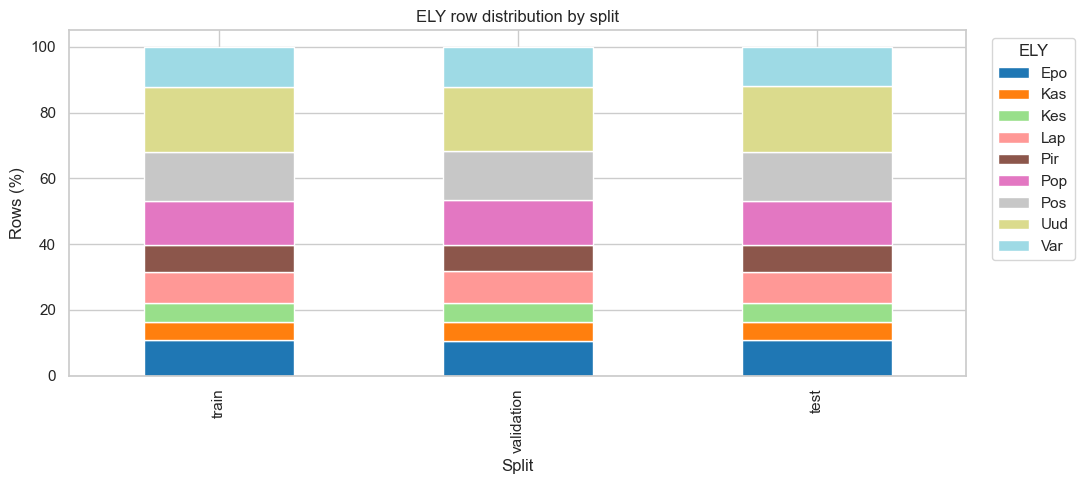

In [6]:
ely_pct = pd.crosstab(df["split"], df["ELY"], normalize="index") * 100
ax = ely_pct.loc[["train", "validation", "test"]].plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20")
ax.set_ylabel("Rows (%)")
ax.set_xlabel("Split")
ax.set_title("ELY row distribution by split")
ax.legend(title="ELY", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Feature Mixtures

The mixtures are cumulative and avoid target-side, redundant, and identifier-like inputs.

In [7]:
FEATURE_MIXTURES = {
    "current": ["URA", "IRI", "target_horizon_years"],
    "current_static": [
        "URA", "IRI", "target_horizon_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
    "current_static_lag": [
        "URA", "IRI", "target_horizon_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
        "prev_URA", "prev_IRI", "Delta_t_years",
    ],
    "current_static_lag_lifecycle": [
        "URA", "IRI", "target_horizon_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
        "prev_URA", "prev_IRI", "Delta_t_years",
        "observed_lifecycle_age_years", "Minor_TP_Count",
    ],
    "current_static_lag_lifecycle_material": [
        "URA", "IRI", "target_horizon_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
        "prev_URA", "prev_IRI", "Delta_t_years",
        "observed_lifecycle_age_years", "Minor_TP_Count",
        "tp_count_interval", "surface_type_current", "material_type_current", "years_since_material_update",
    ],
}

EXCLUDED_INPUTS = {
    "target_next_URA", "target_next_IRI", "target_next_event_date", "target_next_measurement_idx",
    "baseline_persist_URA", "baseline_persist_IRI", "measurements_remaining_in_lifecycle",
    "has_next_measurement_in_lifecycle", "year", "Initial_URA", "Measurement_Idx", "has_TP_interval",
    "is_major_reset", "is_phantom_reset", "Tie", "Aosa", "Aet", "Losa", "Let", "ELY",
    "tp_surface_type", "tp_material_type",
}

all_requested_features = set().union(*[set(v) for v in FEATURE_MIXTURES.values()])
forbidden = sorted(all_requested_features & EXCLUDED_INPUTS)
if forbidden:
    raise ValueError(f"Excluded fields found in feature mixtures: {forbidden}")

missing_features = sorted(all_requested_features - set(df.columns))
if missing_features:
    raise ValueError(f"Feature mixtures reference missing columns: {missing_features}")

display(pd.DataFrame(
    [(name, len(cols), ", ".join(cols)) for name, cols in FEATURE_MIXTURES.items()],
    columns=["feature_mixture", "n_features", "features"],
))

,feature_mixture,n_features,features
0,current,3,"URA, IRI, target_horizon_years"
1,current_static,8,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
2,current_static_lag,11,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
3,current_static_lag_lifecycle,13,"URA, IRI, target_horizon_years, KVL, KVL_raska..."
4,current_static_lag_lifecycle_material,17,"URA, IRI, target_horizon_years, KVL, KVL_raska..."


## 7. Input Encoding Visualization

This section shows how raw model inputs become encoded model inputs. Categorical variables become one-hot columns; numeric variables are imputed and optionally scaled.

In [8]:
CATEGORICAL_FEATURES = {"Toim_lk", "surface_type_current", "material_type_current"}


def make_one_hot_encoder():
    params = {"handle_unknown": "ignore"}
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)


def split_feature_types(features):
    features = list(features)
    categorical = [c for c in features if c in CATEGORICAL_FEATURES]
    numeric = [c for c in features if c not in categorical]
    return numeric, categorical


def build_preprocessor(features, scale_numeric: bool) -> ColumnTransformer:
    numeric, categorical = split_feature_types(features)
    transformers = []

    if numeric:
        steps = [("imputer", SimpleImputer(strategy="median"))]
        if scale_numeric:
            steps.append(("scaler", StandardScaler()))
        transformers.append(("num", Pipeline(steps), numeric))

    if categorical:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", make_one_hot_encoder()),
        ])
        transformers.append(("cat", cat_pipe, categorical))

    return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=True)


schema_rows = []
for feature in FEATURE_MIXTURES["current_static_lag_lifecycle_material"]:
    if feature in CATEGORICAL_FEATURES:
        preprocessing = "fill missing; one-hot encode"
        encoded = "one-hot columns"
    elif feature in {"URA", "IRI", "target_horizon_years", "prev_URA", "prev_IRI", "Delta_t_years"}:
        preprocessing = "median impute; scale for linear/ridge"
        encoded = "numeric column"
    else:
        preprocessing = "median impute"
        encoded = "numeric column"
    schema_rows.append({
        "feature": feature,
        "raw_dtype": str(df[feature].dtype),
        "preprocessing": preprocessing,
        "encoded_representation": encoded,
    })

display(pd.DataFrame(schema_rows))

example_features = FEATURE_MIXTURES["current_static_lag_lifecycle_material"]
train_df_for_example = df.loc[df["split"].eq("train")]
example_raw = train_df_for_example[example_features].head(1).copy()
example_preprocess = build_preprocessor(example_features, scale_numeric=True)
example_preprocess.fit(train_df_for_example[example_features].head(min(10_000, len(train_df_for_example))))
encoded = example_preprocess.transform(example_raw)
encoded_names = example_preprocess.get_feature_names_out()

print("Raw example input:")
display(example_raw)
print("First encoded feature values for the same row:")
display(pd.DataFrame({"encoded_feature": encoded_names[:30], "value": encoded[0, :30]}))

,feature,raw_dtype,preprocessing,encoded_representation
0,URA,float64,median impute; scale for linear/ridge,numeric column
1,IRI,float64,median impute; scale for linear/ridge,numeric column
2,target_horizon_years,float64,median impute; scale for linear/ridge,numeric column
3,KVL,float64,median impute,numeric column
4,KVL_raskas,float64,median impute,numeric column
5,KVL_kaista,float64,median impute,numeric column
6,Nopeus,int64,median impute,numeric column
7,Toim_lk,object,fill missing; one-hot encode,one-hot columns
8,prev_URA,float64,median impute; scale for linear/ridge,numeric column
9,prev_IRI,float64,median impute; scale for linear/ridge,numeric column


Raw example input:


,URA,IRI,target_horizon_years,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk,prev_URA,prev_IRI,Delta_t_years,observed_lifecycle_age_years,Minor_TP_Count,tp_count_interval,surface_type_current,material_type_current,years_since_material_update
1,1.4,1.5,4.180698,182.0,23.0,80.0,80,yhdys,NaN,NaN,NaN,0.0,1,1,PAB,new,8.711841


First encoded feature values for the same row:


,encoded_feature,value
0,num__URA,-1.862666
1,num__IRI,0.576605
2,num__target_horizon_years,3.688975
3,num__KVL,-1.556506
4,num__KVL_raskas,-2.465059
5,num__KVL_kaista,-1.558656
6,num__Nopeus,-1.230048
7,num__prev_URA,-0.152059
8,num__prev_IRI,-0.160492
9,num__Delta_t_years,-0.407862


## 8. Modeling Helpers

These helpers keep preprocessing, training, prediction, and metric calculation consistent across models.

In [9]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }


def sample_training_frame(frame, limit, random_state):
    if limit is None or len(frame) <= limit:
        return frame
    return frame.sample(n=limit, random_state=random_state)


@dataclass
class ModelSpec:
    name: str
    estimator: object
    scale_numeric: bool
    train_limit: Optional[int]
    feature_mixtures: Optional[List[str]] = None


def make_model_specs():
    return [
        ModelSpec("linear_regression", LinearRegression(), True, TRAIN_SAMPLE_LIMITS["linear_regression"]),
        ModelSpec("ridge", Ridge(alpha=1.0, random_state=RANDOM_STATE), True, TRAIN_SAMPLE_LIMITS["ridge"]),
        ModelSpec(
            "random_forest",
            RandomForestRegressor(
                n_estimators=300, min_samples_leaf=5, max_features=0.7,
                n_jobs=-1, random_state=RANDOM_STATE,
            ),
            False,
            TRAIN_SAMPLE_LIMITS["random_forest"],
        ),
        ModelSpec(
            "hist_gradient_boosting",
            HistGradientBoostingRegressor(
                loss="squared_error", learning_rate=0.05, max_iter=400,
                max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=0.0,
                early_stopping=True, validation_fraction=0.1, n_iter_no_change=25,
                random_state=RANDOM_STATE,
            ),
            False,
            TRAIN_SAMPLE_LIMITS["hist_gradient_boosting"],
        ),
        ModelSpec(
            "gradient_boosting",
            GradientBoostingRegressor(
                loss="squared_error", learning_rate=0.05, n_estimators=250,
                max_depth=3, subsample=0.8, random_state=RANDOM_STATE,
            ),
            False,
            TRAIN_SAMPLE_LIMITS["gradient_boosting"],
            SECOND_GB_FEATURE_MIXTURES,
        ),
    ]


def fit_pipeline(train_frame, features, target, spec):
    fit_frame = sample_training_frame(train_frame, spec.train_limit, RANDOM_STATE)
    pipe = Pipeline([
        ("preprocess", build_preprocessor(features, scale_numeric=spec.scale_numeric)),
        ("model", clone(spec.estimator)),
    ])
    pipe.fit(fit_frame[features], fit_frame[target])
    return pipe, len(fit_frame)


def evaluate_model_on_frame(pipe, eval_frame, features, target):
    y_pred = pipe.predict(eval_frame[features])
    return regression_metrics(eval_frame[target], y_pred), y_pred


def evaluate_persistence(eval_frame, target):
    baseline_col = "URA" if target == "target_next_URA" else "IRI"
    y_pred = eval_frame[baseline_col].to_numpy()
    return regression_metrics(eval_frame[target], y_pred), y_pred

## 9. Validation Grid

The validation grid chooses the best feature mixture for each model family and target. The slower second gradient boosting model is run only on the strongest planned mixture.

In [10]:
train_frame = df.loc[df["split"].eq("train")].copy()
validation_frame = df.loc[df["split"].eq("validation")].copy()
test_frame = df.loc[df["split"].eq("test")].copy()

validation_results = []

for target in TARGETS:
    metrics, _ = evaluate_persistence(validation_frame, target)
    validation_results.append({
        "model": "persistence", "target": target, "target_type": "direct",
        "feature_mixture": "persistence", "split": "validation",
        "train_rows": len(train_frame), "evaluation_rows": len(validation_frame), **metrics,
    })

if RUN_VALIDATION_GRID:
    for spec in make_model_specs():
        mixture_names = spec.feature_mixtures or list(FEATURE_MIXTURES.keys())
        for mixture_name in mixture_names:
            features = FEATURE_MIXTURES[mixture_name]
            for target in TARGETS:
                print(f"Fitting {spec.name} | {mixture_name} | {target}")
                pipe, train_rows_used = fit_pipeline(train_frame, features, target, spec)
                metrics, _ = evaluate_model_on_frame(pipe, validation_frame, features, target)
                validation_results.append({
                    "model": spec.name, "target": target, "target_type": "direct",
                    "feature_mixture": mixture_name, "split": "validation",
                    "train_rows": train_rows_used, "evaluation_rows": len(validation_frame), **metrics,
                })

validation_results_df = pd.DataFrame(validation_results).sort_values(["target", "rmse", "model", "feature_mixture"]).reset_index(drop=True)
display(validation_results_df)
validation_results_df.to_csv(RESULT_DIR / "validation_results.csv", index=False)

Fitting linear_regression | current | target_next_URA
Fitting linear_regression | current | target_next_IRI
Fitting linear_regression | current_static | target_next_URA
Fitting linear_regression | current_static | target_next_IRI
Fitting linear_regression | current_static_lag | target_next_URA
Fitting linear_regression | current_static_lag | target_next_IRI
Fitting linear_regression | current_static_lag_lifecycle | target_next_URA
Fitting linear_regression | current_static_lag_lifecycle | target_next_IRI
Fitting linear_regression | current_static_lag_lifecycle_material | target_next_URA
Fitting linear_regression | current_static_lag_lifecycle_material | target_next_IRI
Fitting ridge | current | target_next_URA
Fitting ridge | current | target_next_IRI
Fitting ridge | current_static | target_next_URA
Fitting ridge | current_static | target_next_IRI
Fitting ridge | current_static_lag | target_next_URA
Fitting ridge | current_static_lag | target_next_IRI
Fitting ridge | current_static_lag

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.233404,0.412745,0.848990
1,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle,validation,2683410,574718,0.234012,0.413856,0.848176
2,hist_gradient_boosting,target_next_IRI,direct,current_static_lag,validation,2683410,574718,0.234915,0.415246,0.847155
3,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,300000,574718,0.235386,0.417947,0.845160
4,random_forest,target_next_IRI,direct,current_static_lag_lifecycle,validation,300000,574718,0.236407,0.419205,0.844226
5,random_forest,target_next_IRI,direct,current_static_lag,validation,300000,574718,0.237052,0.420146,0.843526
6,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,150000,574718,0.239924,0.425252,0.839700
7,hist_gradient_boosting,target_next_IRI,direct,current_static,validation,2683410,574718,0.241378,0.427827,0.837753
8,random_forest,target_next_IRI,direct,current_static,validation,300000,574718,0.245109,0.433434,0.833472
9,hist_gradient_boosting,target_next_IRI,direct,current,validation,2683410,574718,0.244675,0.438860,0.829276


### Validation Summary Figure

This plot is a compact model-selection aid. Final conclusions should use held-out test results.

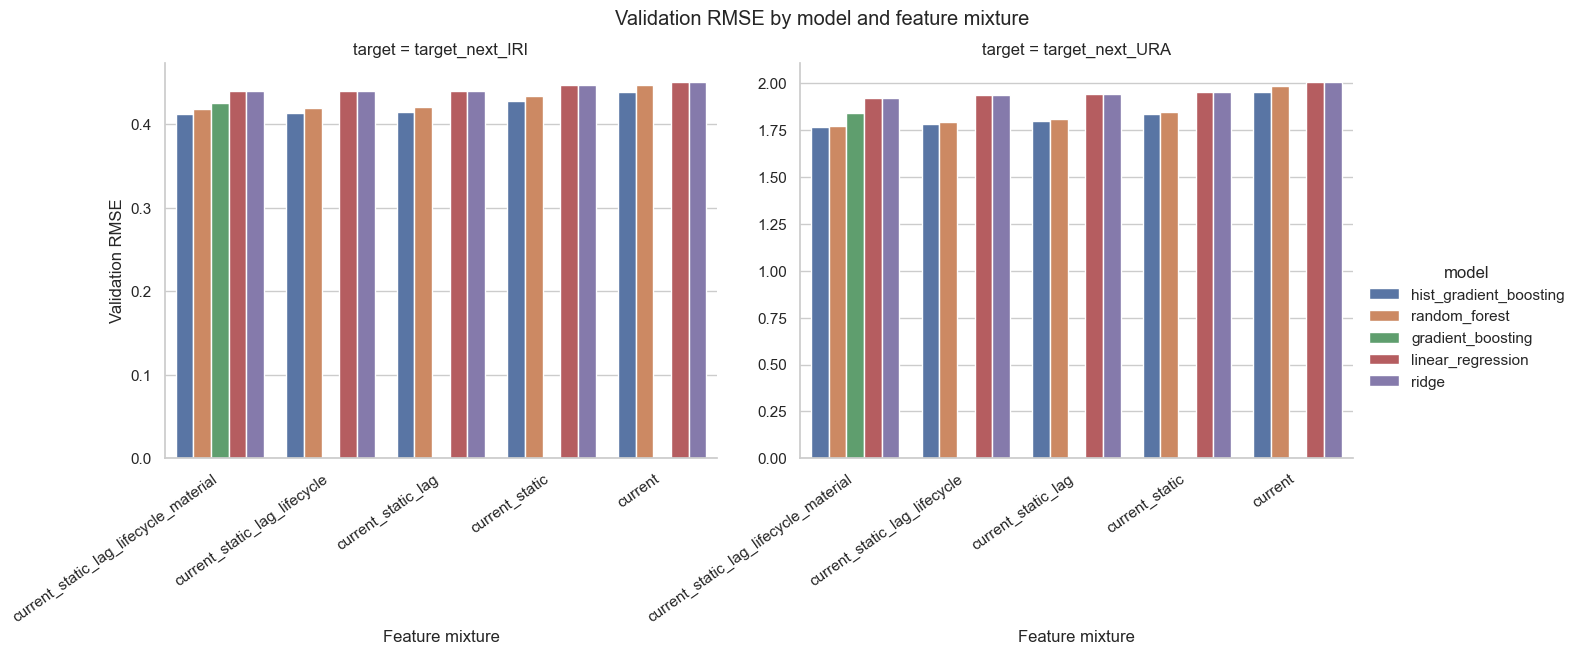

In [12]:
plot_df = validation_results_df.loc[validation_results_df["model"].ne("persistence")].copy()
if not plot_df.empty:
    g = sns.catplot(
        data=plot_df,
        x="feature_mixture",
        y="rmse",
        hue="model",
        col="target",
        kind="bar",
        height=5,
        aspect=1.3,
        sharey=False,
    )
    g.set_xticklabels(rotation=35, ha="right")
    g.set_axis_labels("Feature mixture", "Validation RMSE")
    g.fig.suptitle("Validation RMSE by model and feature mixture", y=1.03)
    plt.show()

## 10. Final Test Evaluation

For each model and target, select the best validation feature mixture by RMSE. Refit the selected configuration on train + validation rows and evaluate once on test.

In [13]:
def select_best_validation_configs(results):
    model_results = results.loc[results["model"].ne("persistence")].copy()
    idx = model_results.groupby(["model", "target"], sort=False)["rmse"].idxmin()
    return model_results.loc[idx].sort_values(["target", "rmse"]).reset_index(drop=True)


best_configs = select_best_validation_configs(validation_results_df)
display(best_configs)

train_val_frame = df.loc[df["split"].isin(["train", "validation"])].copy()
test_results = []
test_prediction_frames = []

for target in TARGETS:
    metrics, pred = evaluate_persistence(test_frame, target)
    test_results.append({
        "model": "persistence", "target": target, "target_type": "direct",
        "feature_mixture": "persistence", "split": "test",
        "train_rows": len(train_val_frame), "evaluation_rows": len(test_frame), **metrics,
    })
    tmp = test_frame[["Segment_ID", "ELY", "event_date", "target_horizon_days", target, "URA", "IRI"]].copy()
    tmp["prediction"] = pred
    tmp["model"] = "persistence"
    tmp["target"] = target
    tmp["target_type"] = "direct"
    tmp["feature_mixture"] = "persistence"
    test_prediction_frames.append(tmp)

if RUN_TEST_EVALUATION:
    specs_by_name = {s.name: s for s in make_model_specs()}
    for _, row in best_configs.iterrows():
        spec = specs_by_name[row["model"]]
        mixture_name = row["feature_mixture"]
        target = row["target"]
        features = FEATURE_MIXTURES[mixture_name]
        print(f"Refitting selected config for test: {spec.name} | {mixture_name} | {target}")
        pipe, train_rows_used = fit_pipeline(train_val_frame, features, target, spec)
        metrics, pred = evaluate_model_on_frame(pipe, test_frame, features, target)
        test_results.append({
            "model": spec.name, "target": target, "target_type": "direct",
            "feature_mixture": mixture_name, "split": "test",
            "train_rows": train_rows_used, "evaluation_rows": len(test_frame), **metrics,
        })
        tmp = test_frame[["Segment_ID", "ELY", "event_date", "target_horizon_days", target, "URA", "IRI"]].copy()
        tmp["prediction"] = pred
        tmp["model"] = spec.name
        tmp["target"] = target
        tmp["target_type"] = "direct"
        tmp["feature_mixture"] = mixture_name
        test_prediction_frames.append(tmp)

test_results_df = pd.DataFrame(test_results).sort_values(["target", "rmse", "model"]).reset_index(drop=True)
display(test_results_df)
test_results_df.to_csv(RESULT_DIR / "test_results_overall.csv", index=False)

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.233404,0.412745,0.848990
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,300000,574718,0.235386,0.417947,0.845160
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,150000,574718,0.239924,0.425252,0.839700
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.250008,0.439871,0.828489
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.250008,0.439871,0.828489
5,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.148788,1.763580,0.840491
6,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,validation,300000,574718,1.137605,1.771828,0.838995
7,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,validation,150000,574718,1.205979,1.837757,0.826790
8,ridge,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.285012,1.922077,0.810531
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.285011,1.922077,0.810531


Refitting selected config for test: hist_gradient_boosting | current_static_lag_lifecycle_material | target_next_IRI
Refitting selected config for test: random_forest | current_static_lag_lifecycle_material | target_next_IRI
Refitting selected config for test: gradient_boosting | current_static_lag_lifecycle_material | target_next_IRI
Refitting selected config for test: linear_regression | current_static_lag_lifecycle_material | target_next_IRI
Refitting selected config for test: ridge | current_static_lag_lifecycle_material | target_next_IRI
Refitting selected config for test: hist_gradient_boosting | current_static_lag_lifecycle_material | target_next_URA
Refitting selected config for test: random_forest | current_static_lag_lifecycle_material | target_next_URA
Refitting selected config for test: gradient_boosting | current_static_lag_lifecycle_material | target_next_URA
Refitting selected config for test: ridge | current_static_lag_lifecycle_material | target_next_URA
Refitting sele

,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,test,300000,575195,0.234435,0.412843,0.848233
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,150000,575195,0.238833,0.419889,0.843008
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
5,persistence,target_next_IRI,direct,persistence,test,3258128,575195,0.263025,0.474531,0.799489
6,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754
7,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,test,300000,575195,1.141090,1.774198,0.839131
8,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,150000,575195,1.209294,1.841161,0.826759
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.286372,1.923522,0.810913


## 11. Direct vs Delta Target Check

This is a focused comparison using histogram gradient boosting and the strongest planned feature mixture. Delta predictions are converted back to actual values before evaluation.

In [14]:
def fit_delta_model(train_frame, eval_frame, target, features, spec):
    current_col = "URA" if target == "target_next_URA" else "IRI"
    delta_col = f"delta_{target}"
    train_work = train_frame.copy()
    train_work[delta_col] = train_work[target] - train_work[current_col]
    pipe, train_rows_used = fit_pipeline(train_work, features, delta_col, spec)
    pred_delta = pipe.predict(eval_frame[features])
    pred_actual = eval_frame[current_col].to_numpy() + pred_delta
    return regression_metrics(eval_frame[target], pred_actual), pred_actual, train_rows_used


if RUN_DELTA_TARGET_COMPARISON:
    delta_spec = next(s for s in make_model_specs() if s.name == "hist_gradient_boosting")
    delta_features_name = "current_static_lag_lifecycle_material"
    delta_features = FEATURE_MIXTURES[delta_features_name]
    delta_rows = []

    for target in TARGETS:
        print(f"Delta comparison: {delta_spec.name} | {target}")
        direct_pipe, direct_train_rows = fit_pipeline(train_val_frame, delta_features, target, delta_spec)
        direct_metrics, _ = evaluate_model_on_frame(direct_pipe, test_frame, delta_features, target)
        delta_metrics, _, delta_train_rows = fit_delta_model(train_val_frame, test_frame, target, delta_features, delta_spec)
        delta_rows.append({
            "model": delta_spec.name, "target": target, "target_type": "direct",
            "feature_mixture": delta_features_name, "split": "test",
            "train_rows": direct_train_rows, "evaluation_rows": len(test_frame), **direct_metrics,
        })
        delta_rows.append({
            "model": delta_spec.name, "target": target, "target_type": "delta_converted_to_actual",
            "feature_mixture": delta_features_name, "split": "test",
            "train_rows": delta_train_rows, "evaluation_rows": len(test_frame), **delta_metrics,
        })

    delta_comparison_df = pd.DataFrame(delta_rows).sort_values(["target", "rmse", "target_type"]).reset_index(drop=True)
    display(delta_comparison_df)
    delta_comparison_df.to_csv(RESULT_DIR / "direct_vs_delta_test_results.csv", index=False)
else:
    delta_comparison_df = pd.DataFrame()

Delta comparison: hist_gradient_boosting | target_next_URA
Delta comparison: hist_gradient_boosting | target_next_IRI


,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,delta_converted_to_actual,current_static_lag_lifecycle_material,test,3258128,575195,0.231849,0.407616,0.852052
1,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
2,hist_gradient_boosting,target_next_URA,delta_converted_to_actual,current_static_lag_lifecycle_material,test,3258128,575195,1.144561,1.754246,0.842729
3,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754


## 12. Horizon and ELY Evaluation

The selected test predictions are evaluated overall, by horizon window, and by ELY area.

In [15]:
def grouped_prediction_metrics(pred_frame, group_col, group_name):
    rows = []
    groups = [("overall", pred_frame)] if group_col is None else list(pred_frame.groupby(group_col, sort=True))
    for value, group in groups:
        if group.empty:
            continue
        target = group["target"].iloc[0]
        rows.append({
            "model": group["model"].iloc[0],
            "target": target,
            "target_type": group["target_type"].iloc[0],
            "feature_mixture": group["feature_mixture"].iloc[0],
            "group_type": group_name,
            "group": value,
            "evaluation_rows": len(group),
            **regression_metrics(group[target], group["prediction"]),
        })
    return pd.DataFrame(rows)


def add_horizon_window(frame):
    out = frame.copy()
    out["horizon_window"] = "outside_windows"
    for name, (lo, hi) in HORIZON_WINDOWS.items():
        out.loc[out["target_horizon_days"].between(lo, hi, inclusive="both"), "horizon_window"] = name
    return out


test_predictions_df = pd.concat(test_prediction_frames, ignore_index=True)
test_predictions_df = add_horizon_window(test_predictions_df)
test_predictions_df.to_parquet(RESULT_DIR / "test_predictions.parquet", index=False)

breakdown_parts = []
for _, pred_group in test_predictions_df.groupby(["model", "target", "target_type", "feature_mixture"], sort=False):
    breakdown_parts.append(grouped_prediction_metrics(pred_group, None, "overall"))
    breakdown_parts.append(grouped_prediction_metrics(pred_group.loc[pred_group["horizon_window"].ne("outside_windows")], "horizon_window", "horizon_window"))
    breakdown_parts.append(grouped_prediction_metrics(pred_group, "ELY", "ELY"))

breakdown_df = pd.concat(breakdown_parts, ignore_index=True).sort_values(["target", "group_type", "group", "rmse", "model"])
display(breakdown_df.head(50))
breakdown_df.to_csv(RESULT_DIR / "test_results_breakdowns.csv", index=False)

,model,target,target_type,feature_mixture,group_type,group,evaluation_rows,mae,rmse,r2
33,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.242976,0.420668,0.848854
47,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.245018,0.423588,0.846748
61,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.249966,0.433011,0.839854
75,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.260387,0.446987,0.829349
89,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Epo,61939,0.260387,0.446987,0.829349
19,persistence,target_next_IRI,direct,persistence,ELY,Epo,61939,0.285333,0.493770,0.791758
34,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.197463,0.346564,0.875160
48,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.198652,0.351942,0.871255
62,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.203089,0.356752,0.867712
76,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,ELY,Kas,31743,0.213005,0.375143,0.853721


### Horizon Window Figure

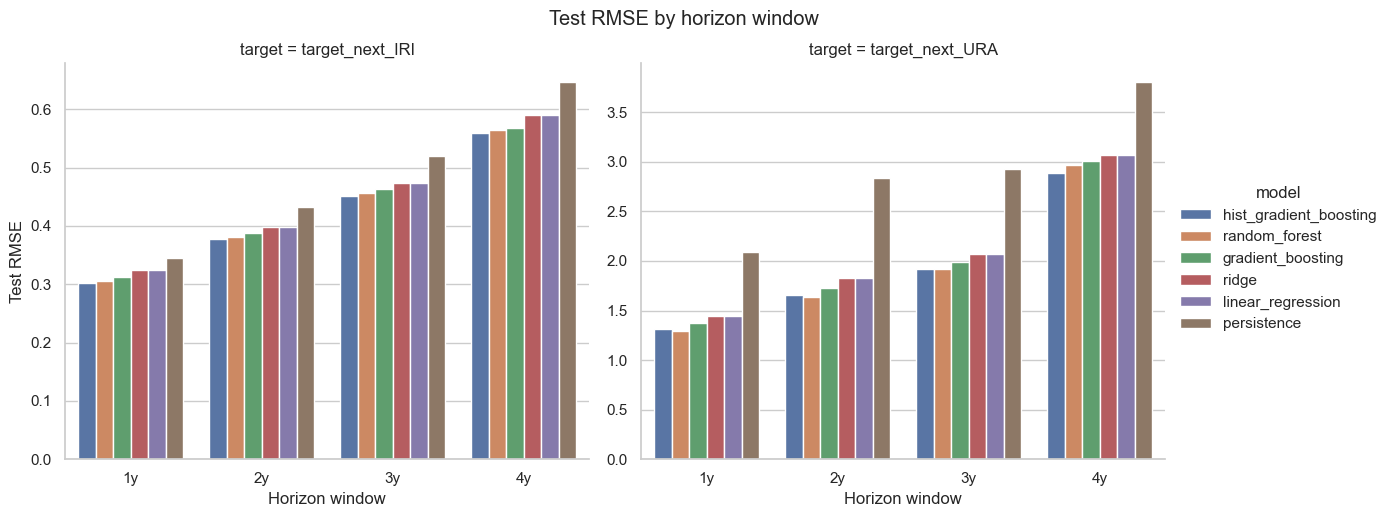

In [16]:
horizon_plot_df = breakdown_df.loc[breakdown_df["group_type"].eq("horizon_window")].copy()
if not horizon_plot_df.empty:
    g = sns.catplot(
        data=horizon_plot_df,
        x="group",
        y="rmse",
        hue="model",
        col="target",
        kind="bar",
        height=5,
        aspect=1.2,
        sharey=False,
        order=list(HORIZON_WINDOWS.keys()),
    )
    g.set_axis_labels("Horizon window", "Test RMSE")
    g.fig.suptitle("Test RMSE by horizon window", y=1.03)
    plt.show()

## 13. Final Result Summary

The CSV/parquet outputs in `results/final_model_comparison/` are the final artifacts for reporting.

In [17]:
print("Best validation configurations:")
display(best_configs)

print("Overall test results:")
display(test_results_df)

print("Per-ELY test RMSE summary:")
display(
    breakdown_df.loc[breakdown_df["group_type"].eq("ELY")]
    .pivot_table(index=["target", "group"], columns="model", values="rmse")
    .round(3)
)

summary_payload = {
    "model_data_path": str(MODEL_DATA_PATH),
    "event_history_path": str(EVENT_HISTORY_PATH),
    "random_state": RANDOM_STATE,
    "split": {"train": TRAIN_FRACTION, "validation": VALIDATION_FRACTION, "test": TEST_FRACTION},
    "feature_mixtures": FEATURE_MIXTURES,
    "train_sample_limits": TRAIN_SAMPLE_LIMITS,
    "horizon_windows": HORIZON_WINDOWS,
}
with open(RESULT_DIR / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print(f"Saved run configuration to {RESULT_DIR / 'run_config.json'}")

Best validation configurations:


,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.233404,0.412745,0.848990
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,300000,574718,0.235386,0.417947,0.845160
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,150000,574718,0.239924,0.425252,0.839700
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.250008,0.439871,0.828489
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,validation,2683410,574718,0.250008,0.439871,0.828489
5,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.148788,1.763580,0.840491
6,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,validation,300000,574718,1.137605,1.771828,0.838995
7,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,validation,150000,574718,1.205979,1.837757,0.826790
8,ridge,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.285012,1.922077,0.810531
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,validation,2683410,574718,1.285011,1.922077,0.810531


Overall test results:


,model,target,target_type,feature_mixture,split,train_rows,evaluation_rows,mae,rmse,r2
0,hist_gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.232244,0.407645,0.852031
1,random_forest,target_next_IRI,direct,current_static_lag_lifecycle_material,test,300000,575195,0.234435,0.412843,0.848233
2,gradient_boosting,target_next_IRI,direct,current_static_lag_lifecycle_material,test,150000,575195,0.238833,0.419889,0.843008
3,linear_regression,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
4,ridge,target_next_IRI,direct,current_static_lag_lifecycle_material,test,3258128,575195,0.248870,0.434029,0.832256
5,persistence,target_next_IRI,direct,persistence,test,3258128,575195,0.263025,0.474531,0.799489
6,hist_gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.150635,1.765230,0.840754
7,random_forest,target_next_URA,direct,current_static_lag_lifecycle_material,test,300000,575195,1.141090,1.774198,0.839131
8,gradient_boosting,target_next_URA,direct,current_static_lag_lifecycle_material,test,150000,575195,1.209294,1.841161,0.826759
9,linear_regression,target_next_URA,direct,current_static_lag_lifecycle_material,test,3258128,575195,1.286372,1.923522,0.810913


Per-ELY test RMSE summary:


model                  gradient_boosting  hist_gradient_boosting  linear_regression  persistence  random_forest  ridge
target          group                                                                                                 
target_next_IRI Epo                0.433                   0.421              0.447        0.494          0.424  0.447
                Kas                0.357                   0.347              0.375        0.404          0.352  0.375
                Kes                0.397                   0.386              0.414        0.445          0.390  0.414
                Lap                0.466                   0.447              0.482        0.526          0.457  0.482
                Pir                0.402                   0.390              0.418        0.460          0.393  0.418
                Pop                0.438                   0.427              0.450        0.488          0.432  0.450
                Pos                0.417                   0.404              0.431        0.479          0.411  0.431
                Uud                0.400                   0.387              0.413        0.450          0.394  0.413
                Var                0.434                   0.424              0.447        0.486          0.428  0.447
target_next_URA Epo                1.659                   1.615              1.741        2.561          1.605  1.741
                Kas                1.782                   1.688              1.873        2.546          1.682  1.873
                Kes                1.709                   1.637              1.794        2.473          1.633  1.794
                Lap                2.337                   2.219              2.419        3.033          2.261  2.419
                Pir                1.635                   1.567              1.711        2.589          1.563  1.711
                Pop                2.020                   1.958              2.137        2.786          1.961  2.137
                Pos                1.926                   1.852              1.990        2.635          1.871  1.990
                Uud                1.581                   1.506              1.656        2.518          1.503  1.656
                Var                1.850                   1.765              1.926        2.615          1.788  1.926

Saved run configuration to results\final_model_comparison\run_config.json
